In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [6]:
df = pd.read_csv("heart.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
X = df.drop("target", axis=1)
y = df["target"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8032786885245902


In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[21  7]
 [ 5 28]]


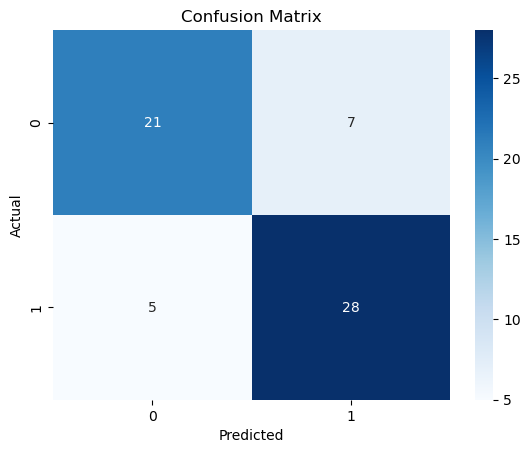

In [15]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



In [17]:
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.8712121212121212


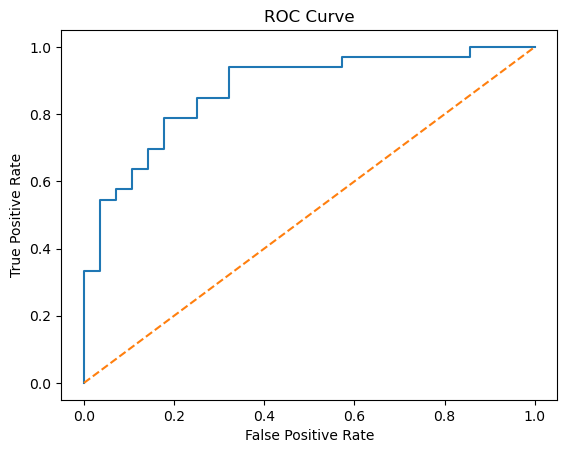

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [19]:
age = int(input("Age: "))
sex = int(input("Sex (1 Male / 0 Female): "))
cp = int(input("Chest Pain Type: "))
trestbps = float(input("Resting BP: "))
chol = float(input("Cholesterol: "))
fbs = int(input("Fasting Blood Sugar (1/0): "))
restecg = int(input("Rest ECG: "))
thalach = float(input("Max Heart Rate: "))
exang = int(input("Exercise Angina (1/0): "))
oldpeak = float(input("Oldpeak: "))
slope = int(input("Slope: "))
ca = int(input("CA: "))
thal = int(input("Thal: "))

sample = pd.DataFrame([{
    "age": age,
    "sex": sex,
    "cp": cp,
    "trestbps": trestbps,
    "chol": chol,
    "fbs": fbs,
    "restecg": restecg,
    "thalach": thalach,
    "exang": exang,
    "oldpeak": oldpeak,
    "slope": slope,
    "ca": ca,
    "thal": thal
}])

sample_scaled = scaler.transform(sample)

result = model.predict(sample_scaled)

if result[0] == 1:
    print("Prediction: Heart Disease Detected")
else:
    print("Prediction: No Heart Disease")

Age:  50
Sex (1 Male / 0 Female):  1
Chest Pain Type:  0
Resting BP:  55
Cholesterol:  55
Fasting Blood Sugar (1/0):  55
Rest ECG:  55
Max Heart Rate:  55
Exercise Angina (1/0):  1
Oldpeak:  55
Slope:  55
CA:  55
Thal:  55


Prediction: No Heart Disease
